In [3]:
# Notebook 01: Data Exploration & Preprocessing
# ASSISTments 2012-2013 Dataset
# For Adaptive Quiz System with Knowledge Tracing

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('default')
sns.set_palette("husl")
%matplotlib inline

print("=" * 60)
print("ASSISTments Dataset Exploration & Preprocessing")
print("=" * 60)

ASSISTments Dataset Exploration & Preprocessing


In [4]:
print("First, let's check what columns are in the dataset...")
print("Reading just the header (first row) to get column names...\n")

# Read only the first row to get column names
first_row = pd.read_csv('../data/raw/2012-2013-data-with-predictions-4-final.csv', nrows=0)

print("All columns in the dataset:")
all_columns = first_row.columns.tolist()
for i, col in enumerate(all_columns, 1):
    print(f"   {i:2d}. {col}")

print(f"\nTotal columns: {len(all_columns)}")

First, let's check what columns are in the dataset...
Reading just the header (first row) to get column names...

All columns in the dataset:
    1. problem_log_id
    2. skill
    3. problem_id
    4. user_id
    5. assignment_id
    6. assistment_id
    7. start_time
    8. end_time
    9. problem_type
   10. original
   11. correct
   12. bottom_hint
   13. hint_count
   14. actions
   15. attempt_count
   16. ms_first_response
   17. tutor_mode
   18. sequence_id
   19. student_class_id
   20. position
   21. type
   22. base_sequence_id
   23. skill_id
   24. teacher_id
   25. school_id
   26. overlap_time
   27. template_id
   28. answer_id
   29. answer_text
   30. first_action
   31. problemlogid
   32. Average_confidence(FRUSTRATED)
   33. Average_confidence(CONFUSED)
   34. Average_confidence(CONCENTRATING)
   35. Average_confidence(BORED)

Total columns: 35


In [5]:
# Define the columns we need for our project (using actual column names)
required_columns = [
    'user_id',              # Student identifier
    'problem_id',           # Question/problem ID
    'skill',                # Skill/topic name (note: 'skill' not 'skill_name')
    'correct',              # 1 if correct, 0 if incorrect
    'ms_first_response',    # Response time in milliseconds
    'sequence_id',          # Chronological sequence
    'assignment_id',        # Quiz/assignment identifier
    'school_id',            # School identifier (optional for analysis)
    'attempt_count'         # Number of attempts on this problem
]

print(f"Columns to load: {required_columns}")

# First, load a sample to check structure
print("\nLoading sample of 1000 rows to verify data...")
sample_df = pd.read_csv('../data/raw/2012-2013-data-with-predictions-4-final.csv',
                        nrows=1000,
                        usecols=required_columns)

print(f"Sample loaded successfully!")
print(f"Shape: {sample_df.shape}")
print(f"\nData types:")
print(sample_df.dtypes)

print(f"\nFirst 5 rows:")
display(sample_df.head())

print(f"\nBasic statistics:")
display(sample_df.describe())

Columns to load: ['user_id', 'problem_id', 'skill', 'correct', 'ms_first_response', 'sequence_id', 'assignment_id', 'school_id', 'attempt_count']

Loading sample of 1000 rows to verify data...
Sample loaded successfully!
Shape: (1000, 9)

Data types:
skill                  str
problem_id           int64
user_id              int64
assignment_id        int64
correct              int64
attempt_count        int64
ms_first_response    int64
sequence_id          int64
school_id            int64
dtype: object

First 5 rows:


,skill,problem_id,user_id,assignment_id,correct,attempt_count,ms_first_response,sequence_id,school_id
0,NaN,557460,61394,565736,1,1,9852,55482,5048
1,Rounding,365981,61394,573819,1,1,21175,34221,5048
2,Multiplication and Division Integers,426415,61394,734130,0,1,8645,39601,5048
3,Proportion,86686,61394,821352,1,1,25728,6912,5048
4,NaN,399669,76592,557216,1,1,286578,37143,7561



Basic statistics:


,problem_id,user_id,assignment_id,correct,attempt_count,ms_first_response,sequence_id,school_id
count,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000
mean,314526.50500,106867.017000,664511.156000,0.733000,1.294000,47682.500000,66038.14900,4573.461000
std,239403.43562,13121.972728,90947.801751,0.442614,1.080153,69210.096164,63980.29327,1966.301105
min,83.00000,61394.000000,366036.000000,0.000000,0.000000,1203.000000,2246.00000,1.000000
25%,89693.00000,93581.000000,582089.000000,0.000000,1.000000,9924.000000,9423.00000,4780.000000
50%,190324.00000,103655.500000,648229.000000,1.000000,1.000000,22662.500000,51003.00000,5450.000000
75%,560522.75000,120130.750000,750596.000000,1.000000,1.000000,53103.500000,120337.25000,5450.000000
max,766659.00000,122616.000000,832827.000000,1.000000,19.000000,539833.000000,208206.00000,9376.000000


In [7]:
print("\n" + "=" * 60)
print("DATA QUALITY ASSESSMENT")
print("=" * 60)

# Check missing values
missing_values = sample_df.isnull().sum()
missing_percent = (missing_values / len(sample_df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing Percentage': missing_percent
}).sort_values('Missing Percentage', ascending=False)

print("Missing Values Analysis:")
display(missing_df[missing_df['Missing Count'] > 0])

# Check unique values
print(f"\nUnique Values per Column:")
for col in required_columns:
    print(f"{col}: {sample_df[col].nunique():,} unique values")

# Check correctness distribution
print(f"\nCorrectness Distribution:")
correct_dist = sample_df['correct'].value_counts()
print(f"Correct (1): {correct_dist.get(1, 0):,} ({correct_dist.get(1, 0)/len(sample_df)*100:.1f}%)")
print(f"Incorrect (0): {correct_dist.get(0, 0):,} ({correct_dist.get(0, 0)/len(sample_df)*100:.1f}%)")

# Response time statistics
print(f"\nResponse Time Statistics (ms):")
print(f"Min: {sample_df['ms_first_response'].min():.0f}")
print(f"Max: {sample_df['ms_first_response'].max():.0f}")
print(f"Mean: {sample_df['ms_first_response'].mean():.0f}")
print(f"Median: {sample_df['ms_first_response'].median():.0f}")
print(f"95th percentile: {sample_df['ms_first_response'].quantile(0.95):.0f}")


DATA QUALITY ASSESSMENT
Missing Values Analysis:


,Missing Count,Missing Percentage
skill,445,44.5



Unique Values per Column:
user_id: 539 unique values
problem_id: 962 unique values
skill: 107 unique values
correct: 2 unique values
ms_first_response: 985 unique values
sequence_id: 555 unique values
assignment_id: 752 unique values
school_id: 25 unique values
attempt_count: 11 unique values

Correctness Distribution:
Correct (1): 733 (73.3%)
Incorrect (0): 267 (26.7%)

Response Time Statistics (ms):
Min: 1203
Max: 539833
Mean: 47682
Median: 22662
95th percentile: 178494



EXPLORATORY DATA ANALYSIS


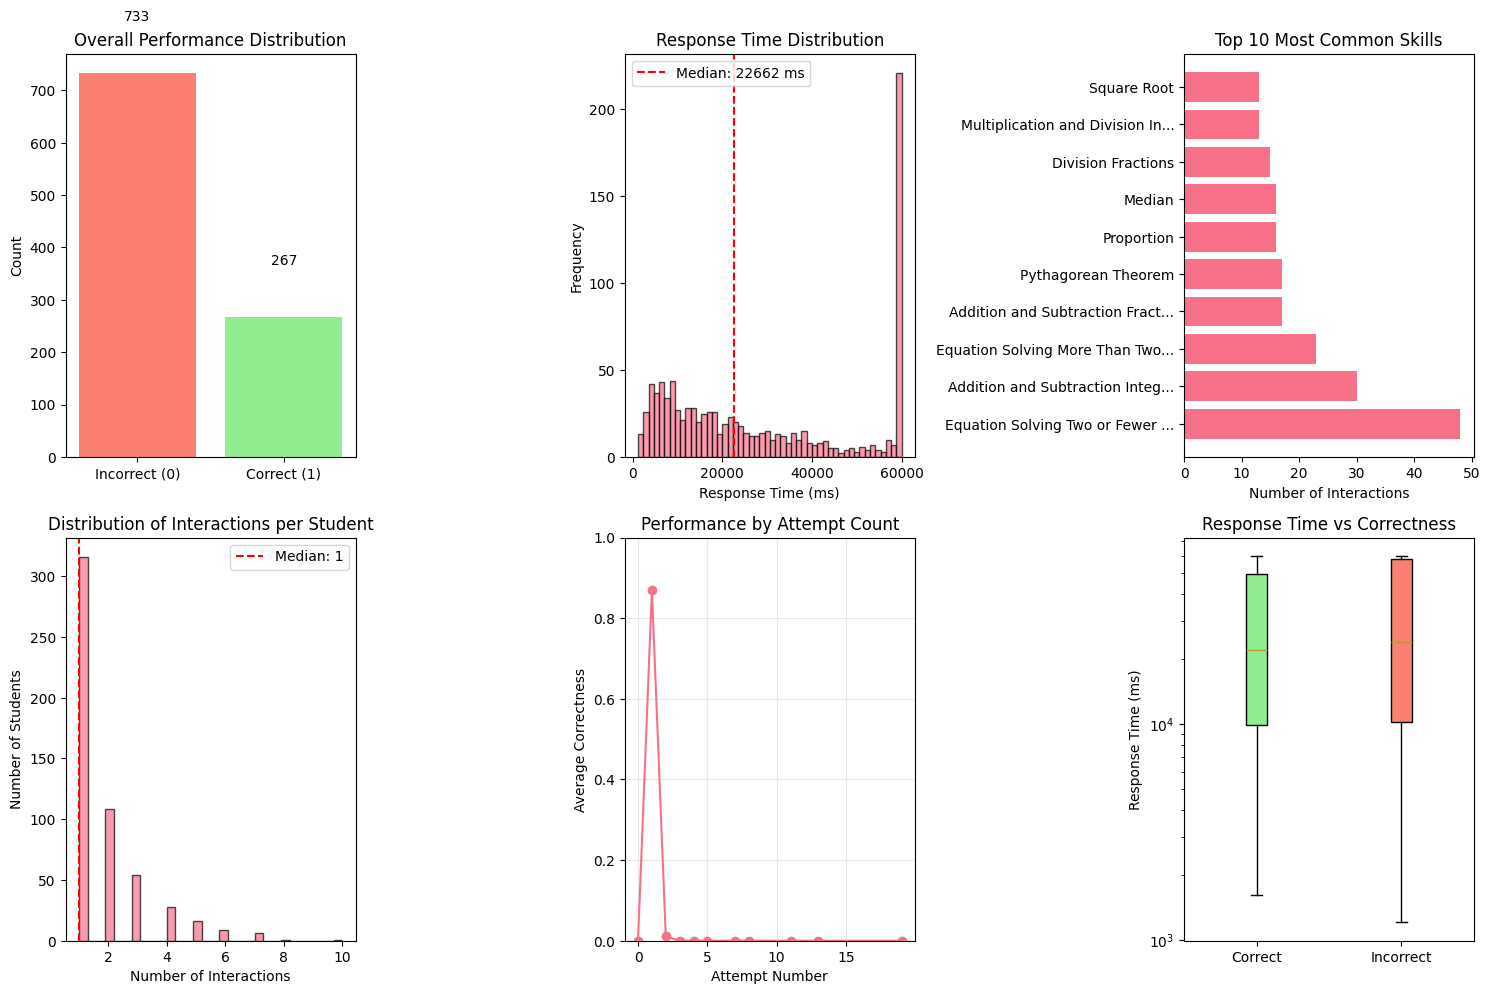

In [8]:
print("\n" + "=" * 60)
print("EXPLORATORY DATA ANALYSIS")
print("=" * 60)

# Create a figure with multiple subplots
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 1. Distribution of correctness
correct_counts = sample_df['correct'].value_counts()
axes[0, 0].bar(['Incorrect (0)', 'Correct (1)'], correct_counts.values, color=['salmon', 'lightgreen'])
axes[0, 0].set_ylabel('Count')
axes[0, 0].set_title('Overall Performance Distribution')
for i, v in enumerate(correct_counts.values):
    axes[0, 0].text(i, v + 100, str(v), ha='center')

# 2. Response time distribution
response_time = sample_df['ms_first_response'].clip(upper=60000)  # Cap at 60 seconds
axes[0, 1].hist(response_time, bins=50, edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('Response Time (ms)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Response Time Distribution')
axes[0, 1].axvline(sample_df['ms_first_response'].median(), color='red', linestyle='--', 
                   label=f"Median: {sample_df['ms_first_response'].median():.0f} ms")
axes[0, 1].legend()

# 3. Top 10 skills by frequency
top_skills = sample_df['skill'].value_counts().head(10)
axes[0, 2].barh(range(len(top_skills)), top_skills.values)
axes[0, 2].set_yticks(range(len(top_skills)))
axes[0, 2].set_yticklabels([s[:30] + '...' if len(s) > 30 else s for s in top_skills.index])
axes[0, 2].set_xlabel('Number of Interactions')
axes[0, 2].set_title('Top 10 Most Common Skills')

# 4. Interactions per student
interactions_per_student = sample_df['user_id'].value_counts()
axes[1, 0].hist(interactions_per_student, bins=30, edgecolor='black', alpha=0.7)
axes[1, 0].set_xlabel('Number of Interactions')
axes[1, 0].set_ylabel('Number of Students')
axes[1, 0].set_title('Distribution of Interactions per Student')
axes[1, 0].axvline(interactions_per_student.median(), color='red', linestyle='--', 
                   label=f"Median: {interactions_per_student.median():.0f}")
axes[1, 0].legend()

# 5. Performance by attempt count
attempt_performance = sample_df.groupby('attempt_count')['correct'].mean()
axes[1, 1].plot(attempt_performance.index, attempt_performance.values, marker='o')
axes[1, 1].set_xlabel('Attempt Number')
axes[1, 1].set_ylabel('Average Correctness')
axes[1, 1].set_title('Performance by Attempt Count')
axes[1, 1].set_ylim([0, 1])
axes[1, 1].grid(True, alpha=0.3)

# 6. Performance vs response time (boxplot)
correct_responses = sample_df[sample_df['correct'] == 1]['ms_first_response'].clip(upper=60000)
incorrect_responses = sample_df[sample_df['correct'] == 0]['ms_first_response'].clip(upper=60000)
bp = axes[1, 2].boxplot([correct_responses, incorrect_responses], 
                         labels=['Correct', 'Incorrect'], 
                         patch_artist=True)
bp['boxes'][0].set_facecolor('lightgreen')
bp['boxes'][1].set_facecolor('salmon')
axes[1, 2].set_ylabel('Response Time (ms)')
axes[1, 2].set_title('Response Time vs Correctness')
axes[1, 2].set_yscale('log')

plt.tight_layout()
plt.show()

In [9]:
print("\n" + "=" * 60)
print("LOADING FULL DATASET")
print("=" * 60)

# Since the dataset is large (3GB), let's load it in chunks
print("Loading full dataset (3GB) in chunks...")
print("This may take 3-5 minutes. Please wait...")

chunk_size = 100000
chunks = []
total_rows = 0

for i, chunk in enumerate(pd.read_csv('../data/raw/2012-2013-data-with-predictions-4-final.csv',
                                       usecols=required_columns,
                                       chunksize=chunk_size)):
    chunks.append(chunk)
    total_rows += len(chunk)
    if (i + 1) % 5 == 0:
        print(f"   Loaded {len(chunks)} chunks ({total_rows:,} rows)...")

df = pd.concat(chunks, ignore_index=True)

print(f"\nFull dataset loaded successfully!")
print(f"Total rows: {len(df):,}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**3:.2f} GB")


LOADING FULL DATASET
Loading full dataset (3GB) in chunks...
This may take 3-5 minutes. Please wait...
   Loaded 5 chunks (500,000 rows)...
   Loaded 10 chunks (1,000,000 rows)...
   Loaded 15 chunks (1,500,000 rows)...
   Loaded 20 chunks (2,000,000 rows)...
   Loaded 25 chunks (2,500,000 rows)...
   Loaded 30 chunks (3,000,000 rows)...
   Loaded 35 chunks (3,500,000 rows)...
   Loaded 40 chunks (4,000,000 rows)...
   Loaded 45 chunks (4,500,000 rows)...
   Loaded 50 chunks (5,000,000 rows)...
   Loaded 55 chunks (5,500,000 rows)...
   Loaded 60 chunks (6,000,000 rows)...

Full dataset loaded successfully!
Total rows: 6,123,270
Memory usage: 0.48 GB


In [10]:
print("\n" + "=" * 60)
print("DATA CLEANING")
print("=" * 60)

initial_shape = df.shape
print(f"Initial shape: {initial_shape}")

# 1. Remove rows with missing critical values
print("\nRemoving missing critical values...")
critical_cols = ['user_id', 'skill', 'correct']
for col in critical_cols:
    missing = df[col].isnull().sum()
    if missing > 0:
        print(f"   Missing {col}: {missing:,} ({missing/len(df)*100:.2f}%)")
        df = df.dropna(subset=[col])

print(f"After removal: {len(df):,} rows")

# 2. Handle missing response times
print("\nHandling missing response times...")
missing_response = df['ms_first_response'].isnull().sum()
if missing_response > 0:
    print(f"Missing response times: {missing_response:,} ({missing_response/len(df)*100:.2f}%)")
    median_response = df['ms_first_response'].median()
    df['ms_first_response'] = df['ms_first_response'].fillna(median_response)
    print(f"Filled with median: {median_response:.0f} ms")
else:
    print(f"No missing response times!")

# 3. Clean skill names
print("\nCleaning skill names...")
print(f"Unique skills before cleaning: {df['skill'].nunique():,}")

# Remove leading/trailing spaces
df['skill'] = df['skill'].astype(str).str.strip()

# Handle multiple skills (take first skill if separated by ~~)
df['skill'] = df['skill'].str.split('~~').str[0]

# Remove rows with empty or 'nan' skill names
df = df[~df['skill'].isin(['', 'nan', 'None'])]
print(f"Unique skills after cleaning: {df['skill'].nunique():,}")
print(f"Rows after skill cleaning: {len(df):,}")

# 4. Remove extreme outliers in response time (99.9th percentile)
print("\nRemoving response time outliers...")
response_99_9 = df['ms_first_response'].quantile(0.999)
df = df[df['ms_first_response'] <= response_99_9]
print(f"Kept responses ≤ {response_99_9:.0f} ms")
print(f"Rows after outlier removal: {len(df):,}")

# 5. Ensure correct is binary
print("\nEnsuring correctness is binary...")
df['correct'] = df['correct'].astype(int)
print(f"Correct values: {df['correct'].unique()}")


DATA CLEANING
Initial shape: (6123270, 9)

Removing missing critical values...
   Missing skill: 3,493,190 (57.05%)
After removal: 2,630,080 rows

Handling missing response times...
No missing response times!

Cleaning skill names...
Unique skills before cleaning: 198
Unique skills after cleaning: 196
Rows after skill cleaning: 2,630,080

Removing response time outliers...
Kept responses ≤ 566941 ms
Rows after outlier removal: 2,627,449

Ensuring correctness is binary...
Correct values: [1 0]


In [11]:
print("\n" + "=" * 60)
print("STUDENT FILTERING")
print("=" * 60)

# Count interactions per student
student_interactions = df.groupby('user_id').size().reset_index(name='interaction_count')
print(f"Total unique students: {len(student_interactions):,}")
print(f"\nInteractions per student statistics:")
print(f"Mean: {student_interactions['interaction_count'].mean():.1f}")
print(f"Median: {student_interactions['interaction_count'].median():.1f}")
print(f"Min: {student_interactions['interaction_count'].min()}")
print(f"Max: {student_interactions['interaction_count'].max():,}")

# Filter students with at least 10 interactions
min_interactions = 10
valid_students = student_interactions[student_interactions['interaction_count'] >= min_interactions]['user_id']

df_filtered = df[df['user_id'].isin(valid_students)]
removed_students = len(student_interactions) - len(valid_students)
removed_rows = len(df) - len(df_filtered)

print(f"\nAfter keeping students with >= {min_interactions} interactions:")
print(f"Students: {len(valid_students):,} (removed {removed_students:,})")
print(f"Interactions: {len(df_filtered):,} (removed {removed_rows:,})")


STUDENT FILTERING
Total unique students: 28,830

Interactions per student statistics:
Mean: 91.1
Median: 35.0
Min: 1
Max: 2,045

After keeping students with >= 10 interactions:
Students: 22,279 (removed 6,551)
Interactions: 2,597,987 (removed 29,462)


In [12]:
print("\n" + "=" * 60)
print("FEATURE ENGINEERING")
print("=" * 60)

# Create a copy for feature engineering
df_features = df_filtered.copy()

# 1. Sort by user and sequence
print("Creating chronological sequence...")
df_features = df_features.sort_values(['user_id', 'sequence_id']).reset_index(drop=True)

# 2. Add attempt number per student (overall)
df_features['attempt_number'] = df_features.groupby('user_id').cumcount() + 1
print(f"Added 'attempt_number' column")

# 3. Add skill-specific attempt number
df_features['skill_attempt'] = df_features.groupby(['user_id', 'skill']).cumcount() + 1
print(f"Added 'skill_attempt' column")

# 4. Add previous correctness (for sequence modeling)
df_features['previous_correct'] = df_features.groupby('user_id')['correct'].shift(1)
print(f"Added 'previous_correct' column")

# 5. Add response time categories (in seconds)
df_features['response_time_sec'] = df_features['ms_first_response'] / 1000
df_features['response_time_bucket'] = pd.cut(
    df_features['response_time_sec'],
    bins=[0, 5, 15, 30, float('inf')],
    labels=['very_fast', 'fast', 'medium', 'slow']
)
print(f"Added 'response_time_sec' and 'response_time_bucket' columns")

# 6. Calculate streak of correct answers
print("Calculating answer streaks...")
def calculate_streak(group):
    streak = []
    current_streak = 0
    for correct in group:
        if correct == 1:
            current_streak += 1
        else:
            current_streak = 0
        streak.append(current_streak)
    return streak

df_features['streak'] = df_features.groupby('user_id')['correct'].transform(calculate_streak)
print(f"Added 'streak' column")

# 7. Add difficulty proxy (average correctness per problem)
print("Adding problem difficulty...")
problem_difficulty = df_features.groupby('problem_id')['correct'].mean().to_dict()
df_features['problem_difficulty'] = df_features['problem_id'].map(problem_difficulty)
print(f"Added 'problem_difficulty' column")

print(f"\nFeature engineering complete!")
print(f"Final dataset shape: {df_features.shape}")
print(f"\nColumns now available:")
for col in df_features.columns:
    print(f"   • {col}")


FEATURE ENGINEERING
Creating chronological sequence...
Added 'attempt_number' column
Added 'skill_attempt' column
Added 'previous_correct' column
Added 'response_time_sec' and 'response_time_bucket' columns
Calculating answer streaks...
Added 'streak' column
Adding problem difficulty...
Added 'problem_difficulty' column

Feature engineering complete!
Final dataset shape: (2597987, 16)

Columns now available:
   • skill
   • problem_id
   • user_id
   • assignment_id
   • correct
   • attempt_count
   • ms_first_response
   • sequence_id
   • school_id
   • attempt_number
   • skill_attempt
   • previous_correct
   • response_time_sec
   • response_time_bucket
   • streak
   • problem_difficulty


In [13]:
print("\n" + "=" * 60)
print("FINAL DATA VALIDATION")
print("=" * 60)

# Check for any remaining issues
print("1️Checking for missing values:")
missing_check = df_features.isnull().sum()
if missing_check.sum() > 0:
    print("Missing values found:")
    print(missing_check[missing_check > 0])
else:
    print("No missing values found!")

# Final statistics
print("\nFinal dataset statistics:")
print(f"Students: {df_features['user_id'].nunique():,}")
print(f"Interactions: {len(df_features):,}")
print(f"Unique skills: {df_features['skill'].nunique():,}")
print(f"Unique problems: {df_features['problem_id'].nunique():,}")
print(f"Overall accuracy: {df_features['correct'].mean():.2%}")

# Performance by skill
skill_performance = df_features.groupby('skill')['correct'].agg(['count', 'mean'])
skill_performance.columns = ['interactions', 'accuracy']

print(f"\nTop 10 skills by interactions:")
display(skill_performance.nlargest(10, 'interactions'))

print(f"\nBottom 10 skills by accuracy (min 100 interactions):")
min_interactions_skills = skill_performance[skill_performance['interactions'] >= 100]
display(min_interactions_skills.nsmallest(10, 'accuracy'))

# Student engagement metrics
print(f"\nStudent engagement metrics:")
print(f"Avg interactions per student: {len(df_features) / df_features['user_id'].nunique():.1f}")
print(f"Avg unique skills per student: {df_features.groupby('user_id')['skill'].nunique().mean():.1f}")
print(f"Avg response time: {df_features['response_time_sec'].mean():.1f} seconds")


FINAL DATA VALIDATION
1️Checking for missing values:
Missing values found:
school_id                  10
previous_correct        22279
response_time_bucket        1
dtype: int64

Final dataset statistics:
Students: 22,279
Interactions: 2,597,987
Unique skills: 196
Unique problems: 50,749
Overall accuracy: 69.70%

Top 10 skills by interactions:


,interactions,accuracy
skill,,
Equation Solving Two or Fewer Steps,191750,0.719447
Addition and Subtraction Integers,148673,0.721584
Addition and Subtraction Fractions,145674,0.684810
Conversion of Fraction Decimals Percents,98063,0.750681
Multiplication and Division Integers,83763,0.848716
Multiplication and Division Positive Decimals,69596,0.731421
Order of Operations All,66488,0.623210
Multiplication Fractions,65785,0.682678
Division Fractions,62314,0.674070



Bottom 10 skills by accuracy (min 100 interactions):


,interactions,accuracy
skill,,
Division Mixed Fractions,692,0.167630
Multiplication Mixed Fractions,581,0.191050
Addition Mixed Fractions,497,0.211268
Surface Area Pyramid,404,0.242574
Multiplication Positive Decimals,553,0.265823
Division Proper Fractions,582,0.280069
Solving System of Equation,247,0.311741
Choose an Equation from Given Information,436,0.330275
Quadratic Equation Solving,165,0.381818



Student engagement metrics:
Avg interactions per student: 116.6
Avg unique skills per student: 15.6
Avg response time: 52.4 seconds


In [14]:
print("\n" + "=" * 60)
print("SAVING PROCESSED DATA")
print("=" * 60)

import os

# Create directories if they don't exist
os.makedirs('../data/processed', exist_ok=True)
os.makedirs('../data/metadata', exist_ok=True)
os.makedirs('../results/figures', exist_ok=True)

# Save cleaned dataset in Parquet format (efficient)
output_path = '../data/processed/cleaned_data.parquet'
df_features.to_parquet(output_path, index=False)
print(f"Cleaned dataset saved to: {output_path}")
print(f"File size: {os.path.getsize(output_path) / 1024**3:.2f} GB")

# Save skill list
skill_list = df_features['skill'].unique()
skill_df = pd.DataFrame(skill_list, columns=['skill_name'])
skill_df.to_csv('../data/metadata/skill_list.csv', index=False)
print(f"Skill list saved to: ../data/metadata/skill_list.csv")

# Save student summary
student_summary = df_features.groupby('user_id').agg({
    'correct': ['count', 'mean'],
    'skill': 'nunique',
    'response_time_sec': 'mean',
    'streak': 'max'
}).reset_index()
student_summary.columns = ['user_id', 'total_interactions', 'accuracy', 
                          'unique_skills', 'avg_response_time', 'max_streak']
student_summary.to_parquet('../data/processed/student_summary.parquet', index=False)
print(f"Student summary saved to: ../data/processed/student_summary.parquet")

# Save problem difficulty mapping
problem_stats = df_features.groupby('problem_id').agg({
    'correct': ['count', 'mean'],
    'skill': 'first'
}).reset_index()
problem_stats.columns = ['problem_id', 'attempts', 'difficulty', 'skill']
problem_stats.to_csv('../data/metadata/problem_difficulty.csv', index=False)
print(f"Problem difficulty mapping saved to: ../data/metadata/problem_difficulty.csv")

print("\n" + "=" * 60)
print("NOTEBOOK 1 COMPLETED SUCCESSFULLY!")
print("=" * 60)

print("\nSummary:")
print(f"• Loaded and cleaned {len(df_features):,} interactions")
print(f"• Kept {df_features['user_id'].nunique():,} students (with ≥10 interactions)")
print(f"• Identified {df_features['skill'].nunique():,} unique skills")
print(f"• Created {len(df_features.columns)} feature columns")
print(f"\nData saved in:")
print(f"• {output_path}")
print(f"• ../data/processed/student_summary.parquet")
print(f"• ../data/metadata/")
print(f"\nNext step: Run Notebook 02 for BKT implementation")


SAVING PROCESSED DATA
Cleaned dataset saved to: ../data/processed/cleaned_data.parquet
File size: 0.04 GB
Skill list saved to: ../data/metadata/skill_list.csv
Student summary saved to: ../data/processed/student_summary.parquet
Problem difficulty mapping saved to: ../data/metadata/problem_difficulty.csv

NOTEBOOK 1 COMPLETED SUCCESSFULLY!

Summary:
• Loaded and cleaned 2,597,987 interactions
• Kept 22,279 students (with ≥10 interactions)
• Identified 196 unique skills
• Created 16 feature columns

Data saved in:
• ../data/processed/cleaned_data.parquet
• ../data/processed/student_summary.parquet
• ../data/metadata/

Next step: Run Notebook 02 for BKT implementation



SAVING EXPLORATION PLOTS


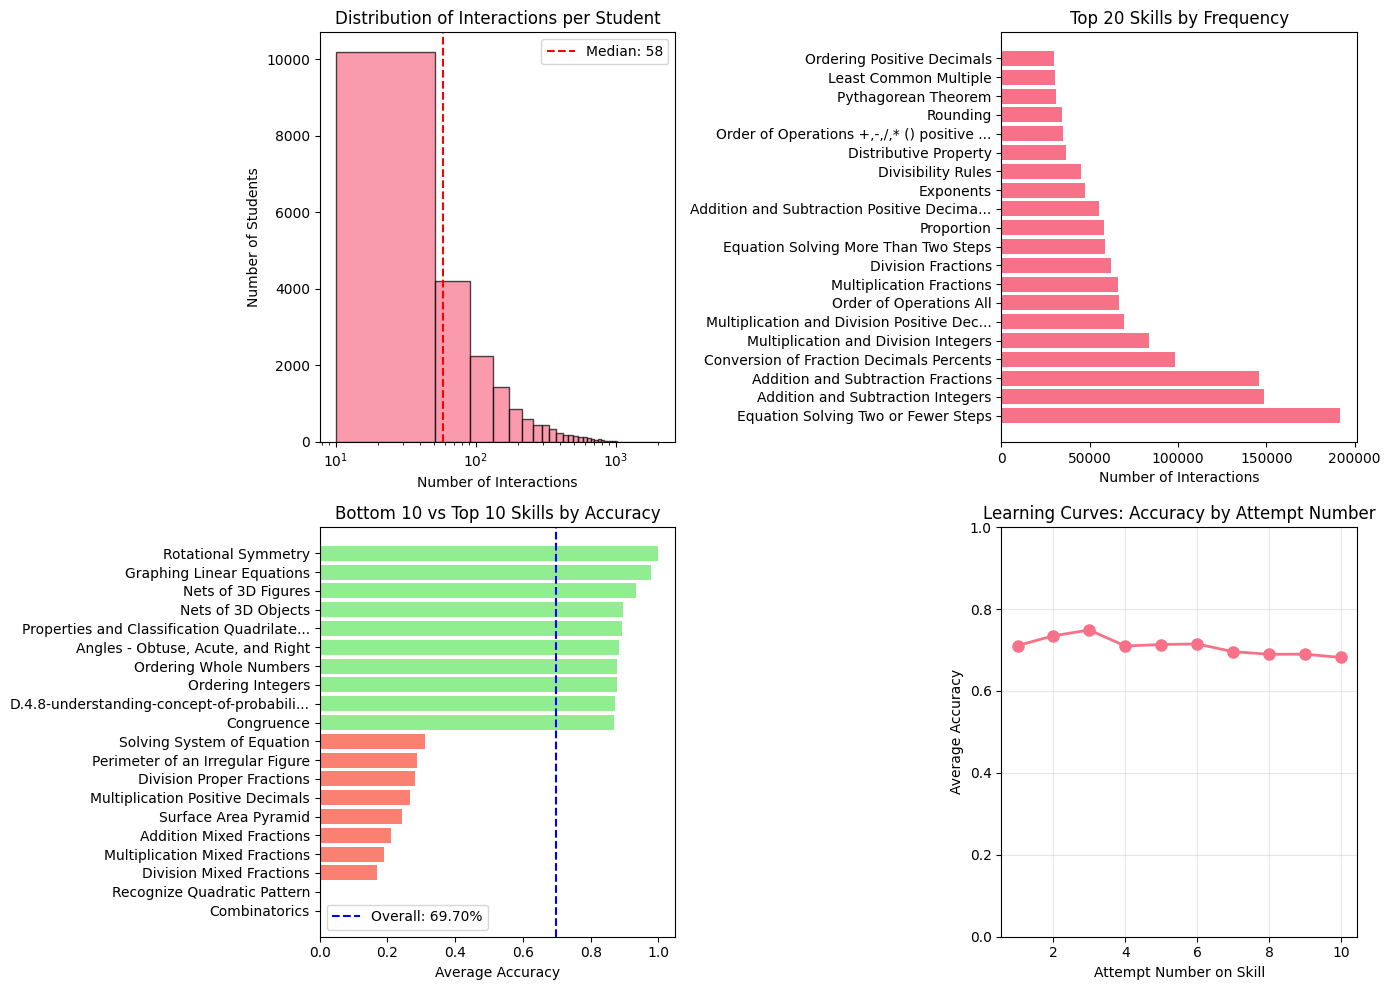

Plots saved to: ../results/figures/dataset_overview.png



In [15]:
print("\n" + "=" * 60)
print("SAVING EXPLORATION PLOTS")
print("=" * 60)

# Create final visualization for presentation
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Distribution of interactions per student
interactions_per_student = df_features.groupby('user_id').size()
axes[0, 0].hist(interactions_per_student, bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Number of Interactions')
axes[0, 0].set_ylabel('Number of Students')
axes[0, 0].set_title('Distribution of Interactions per Student')
axes[0, 0].axvline(interactions_per_student.median(), color='red', linestyle='--', 
                   label=f"Median: {interactions_per_student.median():.0f}")
axes[0, 0].legend()
axes[0, 0].set_xscale('log')

# 2. Skills distribution (top 20)
top_20_skills = df_features['skill'].value_counts().head(20)
axes[0, 1].barh(range(len(top_20_skills)), top_20_skills.values)
axes[0, 1].set_yticks(range(len(top_20_skills)))
axes[0, 1].set_yticklabels([s[:40] + '...' if len(s) > 40 else s for s in top_20_skills.index])
axes[0, 1].set_xlabel('Number of Interactions')
axes[0, 1].set_title('Top 20 Skills by Frequency')

# 3. Performance by skill (heatmap style)
skill_accuracy = df_features.groupby('skill')['correct'].mean().sort_values()
top_10_skills = skill_accuracy.tail(10)
bottom_10_skills = skill_accuracy.head(10)
combined = pd.concat([bottom_10_skills, top_10_skills])
colors = ['salmon']*10 + ['lightgreen']*10
axes[1, 0].barh(range(len(combined)), combined.values, color=colors)
axes[1, 0].set_yticks(range(len(combined)))
axes[1, 0].set_yticklabels([s[:40] + '...' if len(s) > 40 else s for s in combined.index])
axes[1, 0].set_xlabel('Average Accuracy')
axes[1, 0].set_title('Bottom 10 vs Top 10 Skills by Accuracy')
axes[1, 0].axvline(df_features['correct'].mean(), color='blue', linestyle='--', 
                   label=f"Overall: {df_features['correct'].mean():.2%}")
axes[1, 0].legend()

# 4. Learning curves (accuracy by attempt number)
skill_attempt_accuracy = df_features.groupby('skill_attempt')['correct'].mean()
skill_attempt_accuracy = skill_attempt_accuracy[skill_attempt_accuracy.index <= 10]
axes[1, 1].plot(skill_attempt_accuracy.index, skill_attempt_accuracy.values, 
                marker='o', linewidth=2, markersize=8)
axes[1, 1].set_xlabel('Attempt Number on Skill')
axes[1, 1].set_ylabel('Average Accuracy')
axes[1, 1].set_title('Learning Curves: Accuracy by Attempt Number')
axes[1, 1].set_ylim([0, 1])
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/figures/dataset_overview.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Plots saved to: ../results/figures/dataset_overview.png")
print("\n" + "=" * 60)